# Effectiveness Prediction Models — Comprehensive Analysis

**Targets:** team_coordination (T1/T3), cooperative (T2), voice_inclusion (all),
mental_demand (all), satisfaction (T2/T3), decision_confidence (T1), idea_quality (T3),
coord+coop composite (all), HMM-validated composite (all)

**Feature sets:** HMM raw (12), BERT-UMAP (5), Keyword DA (5), NLI DA (5),
Semantic continuity (2), Extra transcript (2), Old HMM states K=5 (5),
New HMM states K=4 (4), Completion/Repetition (2), Audio (4), combinations

**Models:** Ridge, Lasso, ElasticNet, Random Forest

**CV:** LOGO (10 folds) + L2GO (5 folds, recommended)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

sns.set_theme(style='whitegrid', font_scale=1.0)

REPO_ROOT     = Path.cwd() if (Path.cwd() / 'icmi_paper').exists() else Path.cwd().parent
ICMI_RESULTS  = REPO_ROOT / 'icmi_paper' / 'results'
ANALYSIS_RES  = REPO_ROOT / 'analysis' / 'results'
TARGET_PATH   = ANALYSIS_RES / 'perceived_effectiveness_index_participant.tsv'
SELFREPORT_PATH = ANALYSIS_RES / 'collective_features_v20260812' / 'collective_task_selfreport.tsv'

print('Repo root:', REPO_ROOT)

Repo root: c:\Users\amodica\OneDrive - GN Store Nord\Documents\Codes\affectai-data-processing


## 1. Load Base Features (HMM input + audio)

In [2]:
HMM_FEATS = [
    'group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean',
    'group_temp_mean_mean', 'group_et_pupil_mean_mean',
    'tr_silence_duration_s', 'tr_backchannel_count', 'tr_laughter_count',
    'tr_n_active_speakers', 'tr_ovl_count', 'tr_ovl_contested',
    'tr_ovl_time_s',
    # tr_ovl_collaboration_index excluded — derived from deprecated context labels
]
AUDIO_FEATS = ['audio_energy_mean', 'audio_pitch_mean', 'audio_pitch_sd', 'audio_hnr_mean']

KEY = ['group_id', 'task_id', 'window_index']
hmm_win   = pd.read_csv(ICMI_RESULTS / 'hmm_input_features_final.tsv', sep='\t')
audio_win = pd.read_csv(ICMI_RESULTS / 'audio_window_features.tsv', sep='\t')
merged = hmm_win[KEY + [c for c in HMM_FEATS if c in hmm_win.columns]].merge(
    audio_win[KEY + AUDIO_FEATS], on=KEY, how='inner')

# Recover grp-12/T3 (physio off, transcript OK)
enh = pd.read_csv(ICMI_RESULTS / 'enhanced_features_final.tsv', sep='\t')
recovered = enh[(enh['group_id']=='grp-12') & (enh['task_id']=='T3')].copy()
recovered['tr_ovl_contested'] = recovered['tr_ovl_competitive_timing'] + recovered['tr_ovl_floor_fight']
recovered = recovered[KEY + [c for c in HMM_FEATS if c in recovered.columns]]
for c in AUDIO_FEATS:
    recovered[c] = np.nan
merged = pd.concat([merged, recovered], ignore_index=True)
merged = merged[merged['task_id'].isin(['T1','T2','T3'])].reset_index(drop=True)

PHYSIO_Z = ['group_hr_mean_bpm_mean','group_eda_phasic_rate_hz_mean','group_temp_mean_mean','group_et_pupil_mean_mean']
LOG_FEATS = ['tr_silence_duration_s','tr_backchannel_count','tr_laughter_count','tr_ovl_count','tr_ovl_contested','tr_ovl_time_s']
clean = merged.copy()
for col in PHYSIO_Z + AUDIO_FEATS:
    clean[col] = clean.groupby('group_id')[col].transform(lambda x: (x - x.mean())/(x.std(ddof=1)+1e-9))
for col in LOG_FEATS:
    clean[col] = np.log1p(clean[col].clip(lower=0))

feat_task = clean.groupby(['group_id','task_id'])[HMM_FEATS+AUDIO_FEATS].mean().reset_index().rename(columns={'task_id':'task'})
print(f'Base feature table: {feat_task.shape}  ({len(HMM_FEATS)} HMM + {len(AUDIO_FEATS)} audio)')

Base feature table: (28, 18)


## 2. Load NLP + New Features

In [ ]:
BERT_FEATS     = [f'bert_umap{i+1}' for i in range(5)]
KW_FEATS       = ['da_hedge','da_question','da_backchannel','da_statement','da_agreement']
NLI_FEATS_RAW  = ['da_disagreement','da_compromise','da_hedge','da_backchannel','da_offtask']
SEM_FEATS      = ['tr_semantic_continuity','tr_cross_speaker_similarity']
EXTRA_TR_FEATS = ['tr_speaking_entropy','tr_spk_count']
CR_FEATS       = ['n_completions','n_repetitions']

OVL_TIMING_FEATS = [
    'tr_ovl_simultaneous', 'tr_ovl_smooth',
    'tr_ovl_competitive_timing', 'tr_ovl_floor_fight',
    'tr_conflict_overlap_ratio',
]
RICH_PHYSIO_FEATS = [
    'group_hrv_rmssd_ms_mean',
    'group_et_blink_rate_per_min_mean',
    'group_et_gaze_dispersion_mean',
]

# Theory-driven subset of lexical features (avoid redundancy with HMM/overlap features)
LEX_KEY_FEATS = [
    'lex_ttr',             # vocabulary diversity
    'lex_vader_compound',  # overall sentiment
    'lex_we_i_ratio',      # collective framing (we vs I)
    'lex_word_gini',       # participation inequality
    'lex_turn_cohesion',   # Jaccard between consecutive turns (lexical entrainment)
    'lex_dm_elaboration',  # elaboration discourse markers
    'lex_dm_contrast',     # contrast/disagreement markers
    'lex_hedging_count',   # hedging/uncertainty
    'lex_social_composite',# social language composite
    'lex_subordination_ratio', # syntactic complexity
]

def load_window_agg(fpath, feats, key=KEY):
    df = pd.read_csv(fpath, sep='\t')
    avail = [c for c in feats if c in df.columns]
    return (df.groupby(key[:2])[avail].mean().reset_index()
              .rename(columns={'task_id':'task'})), avail

bert_win2 = pd.read_csv(ANALYSIS_RES/'bert_embeddings_window_30s.tsv', sep='\t')
bert_task = (bert_win2[bert_win2['bert_valid']].groupby(['group_id','task_id'])[BERT_FEATS]
             .mean().reset_index().rename(columns={'task_id':'task'}))

kw_task,  KW_FEATS        = load_window_agg(ANALYSIS_RES/'da_keyword_window_30s.tsv',        KW_FEATS)

nli_win = pd.read_csv(ANALYSIS_RES/'da_window_30s.tsv', sep='\t')
NLI_FEATS = [c for c in NLI_FEATS_RAW if c in nli_win.columns]
nli_task = nli_win.groupby(['group_id','task_id'])[NLI_FEATS].mean().reset_index().rename(columns={'task_id':'task'})
nli_task = nli_task.rename(columns={c:f'nli_{c}' for c in NLI_FEATS})
NLI_FEATS = [f'nli_{c}' for c in NLI_FEATS]

sem_task, SEM_FEATS       = load_window_agg(ANALYSIS_RES/'semantic_continuity_window_30s.tsv', SEM_FEATS)

coll_win = pd.read_csv(ANALYSIS_RES/'collective_features_v20260812'/'collective_window_features.tsv', sep='\t')
EXTRA_TR_FEATS    = [c for c in EXTRA_TR_FEATS    if c in coll_win.columns]
OVL_TIMING_FEATS  = [c for c in OVL_TIMING_FEATS  if c in coll_win.columns]
RICH_PHYSIO_FEATS = [c for c in RICH_PHYSIO_FEATS if c in coll_win.columns]
all_coll_feats = list(dict.fromkeys(EXTRA_TR_FEATS + OVL_TIMING_FEATS + RICH_PHYSIO_FEATS))
coll_task = coll_win.groupby(['group_id','task_id'])[all_coll_feats].mean().reset_index().rename(columns={'task_id':'task'})

# Lexical features
lex_win = pd.read_csv(ANALYSIS_RES/'lexical_window_30s.tsv', sep='\t')
ALL_LEX_FEATS = [c for c in lex_win.columns if c.startswith('lex_')]
LEX_KEY_FEATS = [c for c in LEX_KEY_FEATS if c in lex_win.columns]
lex_task = lex_win.groupby(['group_id','task_id'])[ALL_LEX_FEATS].mean().reset_index().rename(columns={'task_id':'task'})

cr_path = ANALYSIS_RES / 'completion_repetition_task.tsv'
if cr_path.exists():
    cr_task = pd.read_csv(cr_path, sep='\t')
    cr_task.columns = cr_task.columns.str.strip()
    if 'task_id' in cr_task.columns:
        cr_task = cr_task.rename(columns={'task_id':'task'})
    CR_FEATS = [c for c in CR_FEATS if c in cr_task.columns]
else:
    cr_task = pd.DataFrame(columns=['group_id','task'])
    CR_FEATS = []

print('BERT:', len(BERT_FEATS), ' KwDA:', len(KW_FEATS), ' NLI DA:', len(NLI_FEATS),
      ' Sem:', len(SEM_FEATS), ' OvlTiming:', len(OVL_TIMING_FEATS),
      ' RichPhysio:', len(RICH_PHYSIO_FEATS), ' Lexical:', len(ALL_LEX_FEATS), ' CR:', len(CR_FEATS))

BERT: 5  KwDA: 5  NLI DA: 5  Sem: 2  ExtraTR: 2  CR: 2


## 3. Load HMM State Proportions

In [4]:
old_hmm = pd.read_csv(ICMI_RESULTS / 'hmm_prediction_results.tsv', sep='\t')
old_hmm = old_hmm.rename(columns={'task_id':'task'})
HMM_OLD_FEATS = [c for c in old_hmm.columns if c.endswith('_pct')]

new_hmm_path = ANALYSIS_RES / 'hmm_state_proportions_expanded.tsv'
if new_hmm_path.exists():
    new_hmm = pd.read_csv(new_hmm_path, sep='\t')
    if 'task_id' in new_hmm.columns:
        new_hmm = new_hmm.rename(columns={'task_id':'task'})
    HMM_NEW_FEATS = [c for c in new_hmm.columns if c.endswith('_pct')]
    print(f'Old HMM states: {HMM_OLD_FEATS}  |  New HMM states: {HMM_NEW_FEATS}')
else:
    new_hmm = pd.DataFrame(columns=['group_id','task'])
    HMM_NEW_FEATS = []
    print('New HMM state file not found')

Old HMM states: ['S0_pct', 'S1_pct', 'S2_pct', 'S3_pct', 'S4_pct']  |  New HMM states: ['S0_pct', 'S1_pct', 'S2_pct', 'S3_pct']


## 4. Load Outcomes

In [5]:
model_df = feat_task.merge(target_task, on=['group_id','task'], how='inner')
dropped = set(zip(target_task['group_id'],target_task['task'])) - set(zip(model_df['group_id'],model_df['task']))

task_dummies = pd.get_dummies(model_df['task'], prefix='task', drop_first=True)
model_df = pd.concat([model_df, task_dummies], axis=1)
TASK_DUMMY_COLS = list(task_dummies.columns)

for df_extra in [bert_task, kw_task, nli_task, sem_task, coll_task, cr_task,
                 old_hmm[['group_id','task']+HMM_OLD_FEATS],
                 (new_hmm[['group_id','task']+HMM_NEW_FEATS] if HMM_NEW_FEATS else None),
                 sr[['group_id','task']+SR_OUTCOMES]]:
    if df_extra is None or df_extra.empty:
        continue
    model_df = model_df.merge(df_extra, on=['group_id','task'], how='left')

for col, tasks in [('team_coordination_mean',['T1','T3']), ('cooperative_mean',['T2'])]:
    if col in model_df.columns:
        mask = model_df['task'].isin(tasks)
        vals = model_df.loc[mask, col]
        model_df.loc[mask, '_coord_coop_z'] = (vals - vals.mean()) / (vals.std(ddof=1) + 1e-9)

print(f'Modeling table: {model_df.shape}  ({len(dropped)} group×task combos missing entirely)')
model_df.head(2)

Participant outcomes: ['perceived_effectiveness_z', 'team_coordination', 'cooperative', 'satisfaction', 'decision_confidence', 'idea_quality']
Selfreport outcomes:  ['voice_inclusion_mean', 'mental_demand_mean', 'team_coordination_mean', 'cooperative_mean', 'satisfaction_mean', 'decision_confidence_mean', 'idea_quality_mean']


## 5. Build Modeling Table

In [6]:
TARGET_TASKS = {
    'cooperative':        (['T2'],          'cooperative_mean'),
    'team_coord':         (['T1','T3'],      'team_coordination_mean'),
    'voice_inclusion':    (['T1','T2','T3'], 'voice_inclusion_mean'),
    'mental_demand':      (['T1','T2','T3'], 'mental_demand_mean'),
    'satisfaction':       (['T2','T3'],      'satisfaction_mean'),
    'decision_conf':      (['T1'],           'decision_confidence_mean'),
    'idea_quality':       (['T3'],           'idea_quality_mean'),
    'coord+coop (z)':     (['T1','T2','T3'], '_coord_coop_z'),
    'composite (HMM val)':(['T1','T2','T3'], 'composite_actual'),
}

MODALITY_SETS = {
    'HMM raw (11)':        HMM_FEATS,
    'Audio (4)':           AUDIO_FEATS,
    'BERT-UMAP (5)':       BERT_FEATS,
    'Keyword DA (5)':      KW_FEATS,
    'NLI DA (5)':          NLI_FEATS,
    'Semantic (2)':        SEM_FEATS,
    'Overlap timing (5)':  OVL_TIMING_FEATS,
    'Rich physio (3)':     RICH_PHYSIO_FEATS,
    'Extra TR (2)':        EXTRA_TR_FEATS,
    'HMM states old K5':   HMM_OLD_FEATS,
    'HMM states new K4':   HMM_NEW_FEATS,
    'HMM+BERT':            HMM_FEATS + BERT_FEATS,
    'HMM+NLI DA':          HMM_FEATS + NLI_FEATS,
    'HMM+OvlTiming':       HMM_FEATS + OVL_TIMING_FEATS,
    'HMM+RichPhysio':      HMM_FEATS + RICH_PHYSIO_FEATS,
    'HMM+ExtraTR':         HMM_FEATS + EXTRA_TR_FEATS,
    'HMM+Semantic':        HMM_FEATS + SEM_FEATS,
    'All NLP':             BERT_FEATS + KW_FEATS + SEM_FEATS + EXTRA_TR_FEATS,
    'All raw':             HMM_FEATS + AUDIO_FEATS + BERT_FEATS + KW_FEATS + SEM_FEATS + OVL_TIMING_FEATS + RICH_PHYSIO_FEATS + EXTRA_TR_FEATS,
}

print(f'{len(TARGET_TASKS)} targets × {len(MODALITY_SETS)} feature sets')

Modeling table: (28, 65)  (2 group×task combos missing entirely)
Groups: 10  Tasks: ['T1', 'T2', 'T3']


,group_id,task,group_hr_mean_bpm_mean,group_eda_phasic_rate_hz_mean,group_temp_mean_mean,group_et_pupil_mean_mean,tr_silence_duration_s,tr_backchannel_count,tr_laughter_count,tr_n_active_speakers,...,S2_pct_y,S3_pct_y,voice_inclusion_mean,mental_demand_mean,team_coordination_mean,cooperative_mean,satisfaction_mean,decision_confidence_mean,idea_quality_mean,_coord_coop_z
0,grp-07,T1,-0.236569,-0.940738,-1.279399,-0.833466,1.564436,0.430133,0.000000,1.888889,...,0.187500,0.250000,6.75,3.0,6.5,NaN,NaN,6.75,NaN,1.073156
1,grp-07,T2,0.088869,-0.008194,0.856327,0.296030,1.471789,0.286756,0.102688,2.111111,...,0.088235,0.088235,4.00,5.0,NaN,3.75,5.25,NaN,NaN,0.080466


## 6. CV Functions

In [7]:
LOGO  = LeaveOneGroupOut()
L2GO  = GroupKFold(n_splits=5)

def run_cv(feature_cols, target_col, task_filter, cv, model='ridge', use_pca=False):
    df = model_df[model_df['task'].isin(task_filter)].copy()
    if target_col not in df.columns or df[target_col].isna().all():
        return np.nan
    task_cols = [c for c in TASK_DUMMY_COLS if df[c].astype(float).nunique() > 1]
    avail_feats = [c for c in feature_cols if c in df.columns]
    if not avail_feats:
        return np.nan
    cols = avail_feats + task_cols
    X = df[cols].values.astype(float)
    y = df[target_col].values.astype(float)
    g = df['group_id'].values
    mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    if mask.sum() < len(np.unique(g[mask])):
        return np.nan
    X_m, y_m, g_m = X[mask], y[mask], g[mask]
    n_pca = min(2, len(avail_feats), X_m.shape[0]-1)

    if model == 'ridge':
        pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01,0.1,1,10,100]))
    elif model == 'lasso':
        pipe = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=10000, random_state=42))
    elif model == 'enet':
        pipe = make_pipeline(StandardScaler(), ElasticNetCV(cv=5, l1_ratio=[0.1,0.5,0.9,1.0], max_iter=10000, random_state=42))
    elif model == 'rf':
        pipe = RandomForestRegressor(n_estimators=200, max_depth=3, random_state=42)
    else:
        raise ValueError(f'Unknown model: {model}')

    if use_pca and n_pca >= 1 and model != 'rf':
        pipe = make_pipeline(StandardScaler(), PCA(n_components=n_pca), pipe.steps[-1][1])

    try:
        preds = cross_val_predict(pipe, X_m, y_m, cv=cv, groups=g_m)
        return round(float(r2_score(y_m, preds)), 3)
    except Exception:
        return np.nan

print('CV functions ready')

CV functions ready


## 7. Define Targets and Feature Sets

In [8]:
TARGET_TASKS = {
    'cooperative':        (['T2'],          'cooperative_mean'),
    'team_coord':         (['T1','T3'],      'team_coordination_mean'),
    'voice_inclusion':    (['T1','T2','T3'], 'voice_inclusion_mean'),
    'mental_demand':      (['T1','T2','T3'], 'mental_demand_mean'),
    'satisfaction':       (['T2','T3'],      'satisfaction_mean'),
    'decision_conf':      (['T1'],           'decision_confidence_mean'),
    'idea_quality':       (['T3'],           'idea_quality_mean'),
    'coord+coop (z)':     (['T1','T2','T3'], '_coord_coop_z'),
    'composite (HMM val)':(['T1','T2','T3'], 'composite_actual'),
}

MODALITY_SETS = {
    'HMM raw (12)':      HMM_FEATS,
    'Audio (4)':         AUDIO_FEATS,
    'BERT-UMAP (5)':     BERT_FEATS,
    'Keyword DA (5)':    KW_FEATS,
    'NLI DA (5)':        NLI_FEATS,
    'Semantic (2)':      SEM_FEATS,
    'Extra TR (2)':      EXTRA_TR_FEATS,
    'HMM states old K5': HMM_OLD_FEATS,
    'HMM states new K4': HMM_NEW_FEATS,
    'HMM+BERT':          HMM_FEATS + BERT_FEATS,
    'HMM+NLI DA':        HMM_FEATS + NLI_FEATS,
    'HMM+ExtraTR':       HMM_FEATS + EXTRA_TR_FEATS,
    'HMM+Semantic':      HMM_FEATS + SEM_FEATS,
    'All NLP':           BERT_FEATS + KW_FEATS + SEM_FEATS + EXTRA_TR_FEATS,
    'All raw':           HMM_FEATS + AUDIO_FEATS + BERT_FEATS + KW_FEATS + SEM_FEATS + EXTRA_TR_FEATS,
}

print(f'{len(TARGET_TASKS)} targets × {len(MODALITY_SETS)} feature sets')

9 targets × 15 feature sets


## 8. Section 1: Feature-Set Comparison (Ridge, L2GO)

Primary analysis — which feature sets predict which outcomes under L2GO?

In [9]:
rows = []
for t_name, (tasks, t_col) in TARGET_TASKS.items():
    for m_name, feats in MODALITY_SETS.items():
        if not feats:
            continue
        r2_logo = run_cv(feats, t_col, tasks, LOGO, 'ridge', False)
        r2_l2go = run_cv(feats, t_col, tasks, L2GO, 'ridge', False)
        r2_pca  = run_cv(feats, t_col, tasks, L2GO, 'ridge', True)
        rows.append({'Target': t_name, 'Feature set': m_name,
                     'LOGO': r2_logo, 'L2GO_raw': r2_l2go, 'L2GO_PCA2': r2_pca})

feat_df = pd.DataFrame(rows)

print('=== L2GO Raw — Ridge ===')
print(feat_df.pivot(index='Feature set', columns='Target', values='L2GO_raw').round(3).to_string())
print()
print('=== L2GO PCA-2 — Ridge ===')
print(feat_df.pivot(index='Feature set', columns='Target', values='L2GO_PCA2').round(3).to_string())

=== L2GO Raw — Ridge ===
Target             composite (HMM val)  cooperative  coord+coop (z)  decision_conf  idea_quality  mental_demand  satisfaction  team_coord  voice_inclusion
Feature set                                                                                                                                               
All NLP                          0.426       -1.207          -0.163         -1.295        -0.620          0.034         0.456      -0.751            0.135
All raw                          0.706       -0.357          -0.002         -1.202        -0.891         -0.123         0.069      -0.088            0.350
Audio (4)                        0.684       -0.663          -0.055         -1.197        -0.904          0.119         0.132      -0.232            0.388
BERT-UMAP (5)                    0.543       -2.372          -0.158         -1.488         0.083          0.145         0.263      -0.235            0.299
Extra TR (2)                     0.750       

## 9. Section 2: Model Comparison (HMM raw, L2GO)

Ridge vs Lasso vs ElasticNet vs Random Forest — all on HMM raw features.

In [10]:
model_rows = []
for t_name, (tasks, t_col) in TARGET_TASKS.items():
    for mdl in ['ridge', 'lasso', 'enet', 'rf']:
        r2 = run_cv(HMM_FEATS, t_col, tasks, L2GO, mdl, False)
        model_rows.append({'Model': mdl.upper().replace('ENET','ElasticNet'),
                           'Target': t_name, 'L2GO_R2': r2})

model_comp = pd.DataFrame(model_rows)
print('=== Model comparison on HMM raw features (L2GO) ===')
print(model_comp.pivot(index='Model', columns='Target', values='L2GO_R2').round(3).to_string())

=== Model comparison on HMM raw features (L2GO) ===
Target      composite (HMM val)  cooperative  coord+coop (z)  decision_conf  idea_quality  mental_demand  satisfaction  team_coord  voice_inclusion
Model                                                                                                                                              
ElasticNet                0.644        0.689          -0.044         -0.685        -1.705          0.242        -0.333      -0.035            0.317
LASSO                     0.668        0.834          -0.097         -0.693        -1.833          0.272        -0.305      -0.268            0.484
RF                        0.708        0.115          -0.021         -0.009        -0.823          0.331         0.064      -0.066            0.226
RIDGE                     0.533        0.376          -0.256         -0.400        -1.075          0.190        -0.107       0.117            0.140


## 10. Heatmap Visualisation

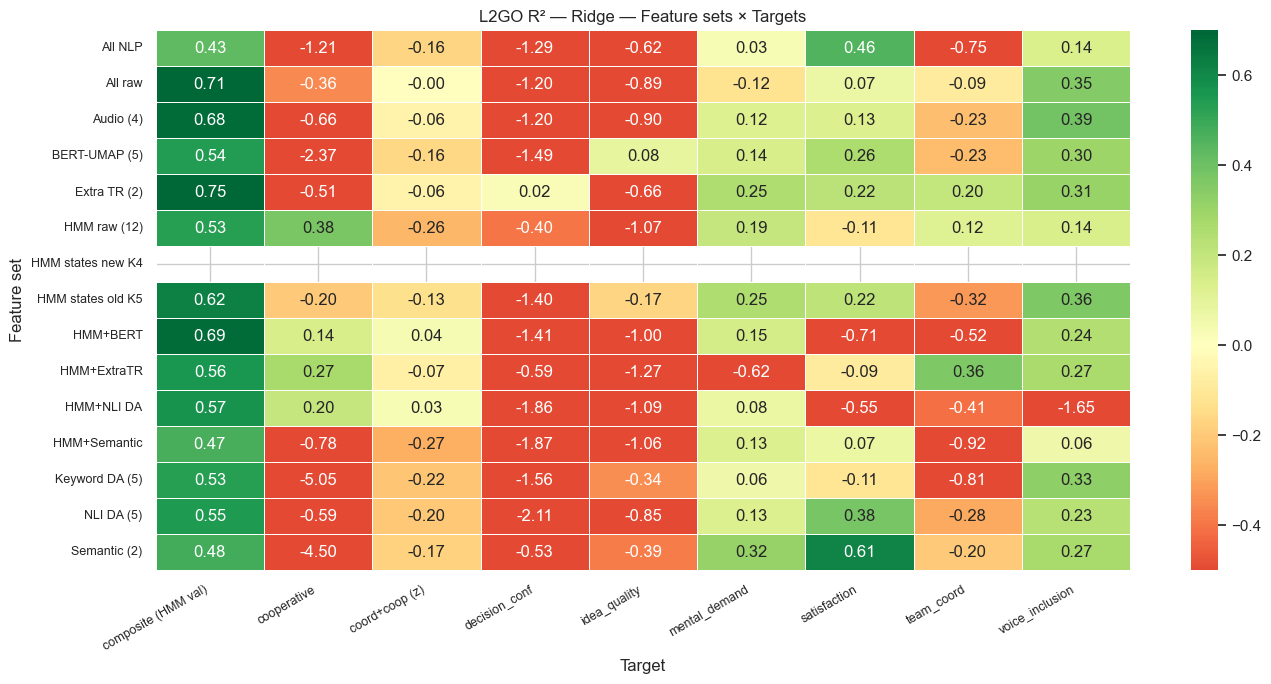

In [11]:
pivot = feat_df.pivot(index='Feature set', columns='Target', values='L2GO_raw')

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot, cmap='RdYlGn', center=0, vmin=-0.5, vmax=0.7,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax)
ax.set_title('L2GO R² — Ridge — Feature sets × Targets', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## 11. Feature Importance (Random Forest on HMM features)

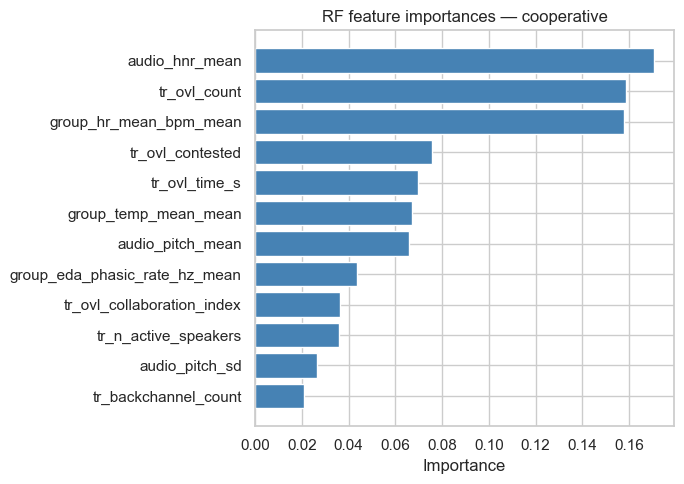

In [12]:
# Fit RF on cooperative (best target) to get feature importances
best_target = ('cooperative', ['T2'], 'cooperative_mean')

df_fit = model_df[model_df['task'].isin(best_target[1])].copy()
task_cols = [c for c in TASK_DUMMY_COLS if df_fit[c].astype(float).nunique() > 1]
all_feats = HMM_FEATS + AUDIO_FEATS + task_cols
avail = [c for c in all_feats if c in df_fit.columns]
X = df_fit[avail].values.astype(float)
y = df_fit[best_target[2]].values.astype(float)
mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
X_m, y_m = X[mask], y[mask]

imp = SimpleImputer(strategy='mean')
X_imp = imp.fit_transform(X_m)
rf = RandomForestRegressor(n_estimators=500, max_depth=3, random_state=42)
rf.fit(X_imp, y_m)

imp_df = pd.Series(rf.feature_importances_, index=avail).sort_values(ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df.index, imp_df.values, color='steelblue')
ax.set_title(f'RF feature importances — {best_target[0]}')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 12. Permutation Tests (p-values for best models)

For each target, test whether the best-performing feature set achieves R² significantly above chance.
With n=28, standard parametric tests are unreliable — permutation testing is the correct approach.
p-value = proportion of permuted R² scores ≥ observed R² (1000 permutations).

In [13]:
from sklearn.model_selection import permutation_test_score

N_PERMS = 1000  # increase to 5000 for publication-quality p-values

# Test the best feature set for each primary target under L2GO
PERM_TARGETS = {
    'cooperative':     (['T2'],          'cooperative_mean',      HMM_FEATS),
    'team_coord':      (['T1','T3'],      'team_coordination_mean', HMM_FEATS + EXTRA_TR_FEATS),
    'voice_inclusion': (['T1','T2','T3'], 'voice_inclusion_mean',  AUDIO_FEATS),
    'mental_demand':   (['T1','T2','T3'], 'mental_demand_mean',    AUDIO_FEATS),
    'composite':       (['T1','T2','T3'], 'composite_actual',      HMM_OLD_FEATS),
}

perm_rows = []
for t_name, (tasks, t_col, feats) in PERM_TARGETS.items():
    df = model_df[model_df['task'].isin(tasks)].copy()
    if t_col not in df.columns or df[t_col].isna().all():
        continue
    task_cols = [c for c in TASK_DUMMY_COLS if df[c].astype(float).nunique() > 1]
    avail = [c for c in feats if c in df.columns] + task_cols
    X = df[avail].values.astype(float)
    y = df[t_col].values.astype(float)
    g = df['group_id'].values
    mask = ~(np.isnan(X).any(axis=1) | np.isnan(y))
    if mask.sum() < len(np.unique(g[mask])):
        continue
    X_m, y_m, g_m = X[mask], y[mask], g[mask]

    pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=[0.01, 0.1, 1, 10, 100]))
    score, perm_scores, pval = permutation_test_score(
        pipe, X_m, y_m, scoring='r2',
        cv=GroupKFold(n_splits=5), groups=g_m,
        n_permutations=N_PERMS, random_state=42, n_jobs=-1
    )
    perm_rows.append({
        'Target': t_name,
        'Feature set': '+'.join([f[:8] for f in feats[:3]]) + ('...' if len(feats) > 3 else ''),
        'Observed R²': round(score, 3),
        'Mean perm R²': round(perm_scores.mean(), 3),
        'p-value': round(pval, 4),
        'Significant': '✓' if pval < 0.10 else ('~' if pval < 0.20 else '✗'),
    })
    print(f'{t_name:20s}  R²={score:.3f}  p={pval:.4f}  {"*" if pval < 0.10 else ""}')

perm_df = pd.DataFrame(perm_rows)
print('\n', perm_df[['Target','Observed R²','Mean perm R²','p-value','Significant']].to_string(index=False))

cooperative           R²=0.097  p=1.0000  
team_coord            R²=-0.496  p=0.1518  
voice_inclusion       R²=0.239  p=0.0260  *
mental_demand         R²=0.068  p=0.0170  *
composite             R²=0.501  p=0.0010  *

          Target  Observed R²  Mean perm R²  p-value Significant
    cooperative        0.097         0.097   1.0000           ✗
     team_coord       -0.496        -1.345   0.1518           ~
voice_inclusion        0.239        -0.237   0.0260           ✓
  mental_demand        0.068        -0.445   0.0170           ✓
      composite        0.501        -0.161   0.0010           ✓
